#  (PR 2)
## Adult Income Binary Classification with an MLP

**Institute:** Red & White Skill Education  
**Subject:** Deep Learning  
**Dataset:** Adult Income / Census Income (`adult.csv`)  
**Framework:** TensorFlow 2.x / Keras + scikit-learn  
**Notebook:** `DL_PR2.ipynb`

### Objective
Predict whether annual income is `>50K` using a tabular MLP, then systematically study activation functions, weight initialization, loss functions, Batch Normalization and optimizers.

The project brief requires all seven tasks in one notebook and emphasizes minority-class Precision, Recall and F1 because the target is imbalanced. fileciteturn0file0L154-L204

> **Important dataset-name mapping:** the supplied CSV uses `educational-num`, `marital-status`, `gender`, `capital-gain`, `capital-loss`, `hours-per-week`, and `native-country`. These correspond to the differently punctuated names used in parts of the project document.

In [5]:
# 0. Imports, reproducibility and output folder
import os, random, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve)
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED=42
np.random.seed(SEED); random.seed(SEED); tf.keras.utils.set_random_seed(SEED)
PLOTS_DIR="plots"; os.makedirs(PLOTS_DIR, exist_ok=True)
EPOCHS_50=50; EPOCHS_30=30; EPOCHS_80=80; BATCH_SIZE=64
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


# Task 1: Data Loading, Cleaning & Exploratory Data Analysis

**Objective:** Load the uploaded CSV, clean missing values, remove redundant columns, encode the target, perform the required EDA, one-hot encode categorical variables, scale only numeric variables, and create a stratified 80/20 split.

The brief requires whitespace stripping, `? → NaN`, dropping rows with missing values, dropping `fnlwgt` and text `education`, target encoding, four EDA plots, OHE, numeric-only scaling and a stratified split. fileciteturn0file0L159-L204

In [6]:
# 1.1 Load and inspect
DATA_PATH="adult.csv"
df=pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print(df.dtypes)
display(df.head())

# Strip whitespace from every object column.
for col in df.select_dtypes(include="object").columns:
    df[col]=df[col].str.strip()

# Replace question marks with missing values.
df.replace("?", np.nan, inplace=True)
print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False))

Shape: (48842, 15)
age                 int64
workclass          object
fnlwgt              int64
education          object
educational-num     int64
marital-status     object
occupation         object
relationship       object
race               object
gender             object
capital-gain        int64
capital-loss        int64
hours-per-week      int64
native-country     object
income             object
dtype: object


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K



Missing values:


occupation         2809
workclass          2799
native-country      857
fnlwgt                0
education             0
educational-num       0
age                   0
marital-status        0
relationship          0
gender                0
race                  0
capital-gain          0
capital-loss          0
hours-per-week        0
income                0
dtype: int64

In [7]:
# 1.2 Drop rows with missing values
before=len(df)
df.dropna(inplace=True)
print("Rows before:", before)
print("Rows after :", len(df))
print("Removed    :", before-len(df))

# 1.3 Drop fnlwgt and redundant text education.
df.drop(columns=["fnlwgt","education"], inplace=True)
print("Shape after required drops:", df.shape)

Rows before: 48842
Rows after : 45222
Removed    : 3620
Shape after required drops: (45222, 13)


### Missing-value justification

The brief specifically asks to drop rows with missing values. The missing fields are categorical (`workclass`, `occupation`, `native-country`), so mode imputation could artificially inflate the most common category. For the **uploaded full 48,842-row CSV**, the actual number of missing rows differs from the approximate count printed in the project brief; this notebook reports the supplied data rather than silently changing it.

income
0    34014
1    11208
Name: count, dtype: int64
income
0    75.22
1    24.78
Name: proportion, dtype: float64


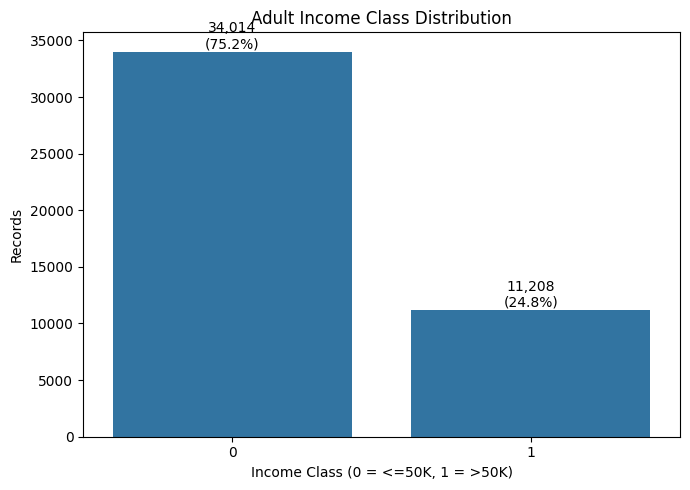

In [8]:
# 1.4 Encode target
# <=50K = 0, >50K = 1
df["income"]=(df["income"]==">50K").astype(int)
print(df["income"].value_counts().sort_index())
print((df["income"].value_counts(normalize=True).sort_index()*100).round(2))

# Class balance plot with annotations.
plt.figure(figsize=(7,5))
ax=sns.countplot(data=df,x="income")
plt.title("Adult Income Class Distribution")
plt.xlabel("Income Class (0 = <=50K, 1 = >50K)"); plt.ylabel("Records")
for p in ax.patches:
    n=int(p.get_height()); pct=100*n/len(df)
    ax.annotate(f"{n:,}\n({pct:.1f}%)",(p.get_x()+p.get_width()/2,p.get_height()),ha="center",va="bottom")
plt.tight_layout(); plt.savefig(f"{PLOTS_DIR}/eda_class_balance.png",dpi=150); plt.show()

### Class imbalance interpretation

The cleaned uploaded data is about **75% class 0 and 25% class 1**. A majority-class model can therefore obtain around 75% accuracy without identifying any `>50K` records. This is why the practical asks us to track class-1 Precision, Recall and F1 rather than accuracy alone. fileciteturn0file0L181-L187

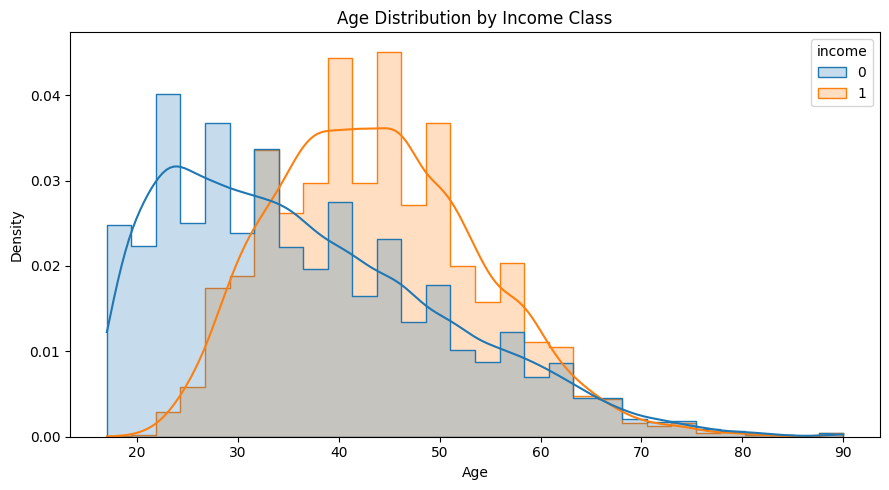

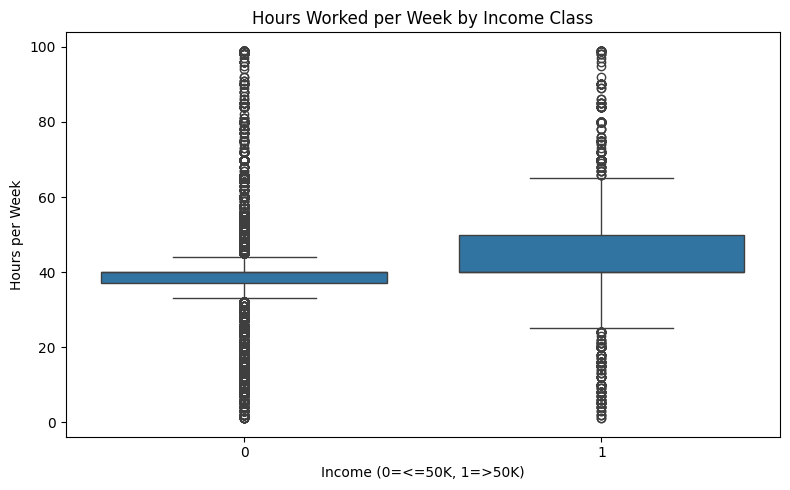

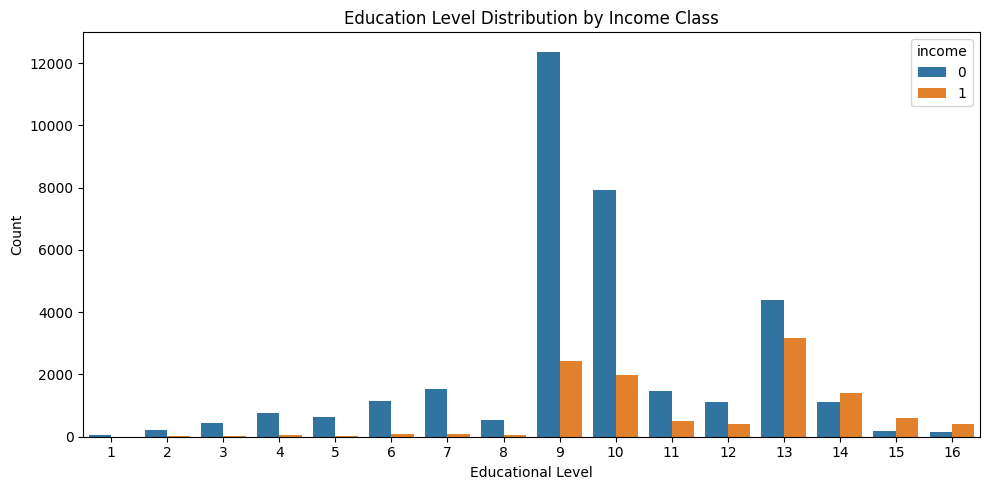

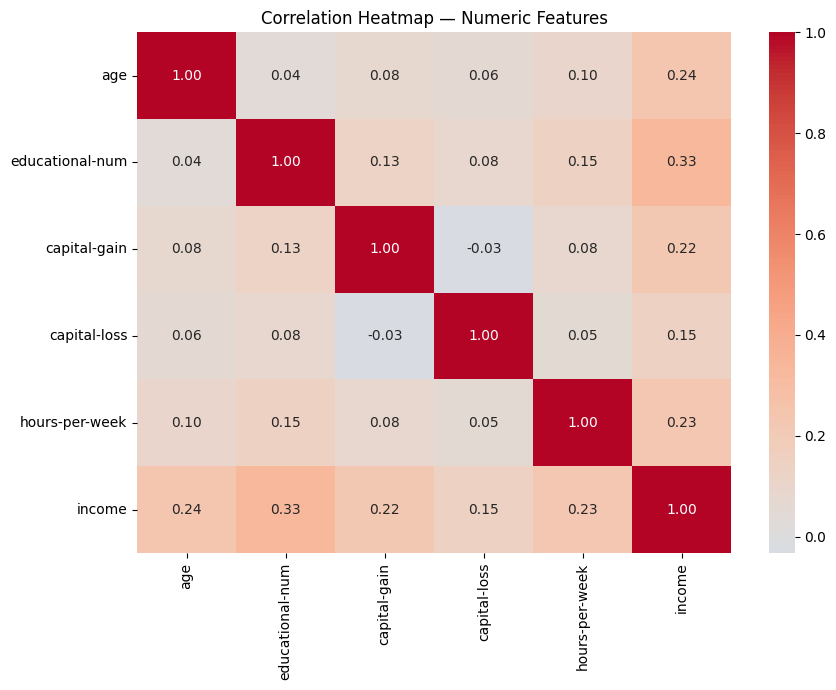

In [9]:
# 1.5 Required EDA — four plots
fig,ax=plt.subplots(figsize=(9,5))
sns.histplot(data=df,x="age",hue="income",bins=30,kde=True,element="step",stat="density",common_norm=False,ax=ax)
ax.set_title("Age Distribution by Income Class"); ax.set_xlabel("Age"); ax.set_ylabel("Density")
plt.tight_layout(); plt.savefig(f"{PLOTS_DIR}/eda_age_by_income.png",dpi=150); plt.show()

plt.figure(figsize=(8,5)); sns.boxplot(data=df,x="income",y="hours-per-week")
plt.title("Hours Worked per Week by Income Class"); plt.xlabel("Income (0=<=50K, 1=>50K)"); plt.ylabel("Hours per Week")
plt.tight_layout(); plt.savefig(f"{PLOTS_DIR}/eda_hours_boxplot.png",dpi=150); plt.show()

plt.figure(figsize=(10,5)); sns.countplot(data=df,x="educational-num",hue="income")
plt.title("Education Level Distribution by Income Class"); plt.xlabel("Educational Level"); plt.ylabel("Count")
plt.tight_layout(); plt.savefig(f"{PLOTS_DIR}/eda_education_by_income.png",dpi=150); plt.show()

plt.figure(figsize=(9,7)); sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True,fmt=".2f",cmap="coolwarm",center=0)
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout(); plt.savefig(f"{PLOTS_DIR}/eda_correlation_heatmap.png",dpi=150); plt.show()

### EDA interpretation

- **Age:** higher-income observations are more concentrated among middle-aged/older individuals.
- **Hours per week:** the `>50K` group generally has a higher central tendency, although there is overlap.
- **Education:** higher `educational-num` levels are more represented in the `>50K` class.
- **Correlation:** numeric correlation captures linear relationships only; an MLP can learn nonlinear interactions.

In [10]:
# 1.6 OHE + stratified 80/20 split + numeric-only StandardScaler
X_raw=df.drop(columns="income"); y=df["income"].copy()
categorical_cols=X_raw.select_dtypes(include="object").columns.tolist()
numeric_cols=["age","educational-num","capital-gain","capital-loss","hours-per-week"]
X=pd.get_dummies(X_raw,columns=categorical_cols,drop_first=True,dtype=np.float32)
print("OHE feature shape:",X.shape)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=SEED,stratify=y)
print("Train:",X_train.shape,"Test:",X_test.shape)
print("Train class ratio:"); display(y_train.value_counts(normalize=True).sort_index())
print("Test class ratio:"); display(y_test.value_counts(normalize=True).sort_index())

# Fit scaler on training data only to prevent test leakage.
scaler=StandardScaler()
X_train=X_train.copy(); X_test=X_test.copy()
X_train[numeric_cols]=scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]=scaler.transform(X_test[numeric_cols])
print("Scaled numeric columns only:",numeric_cols)

OHE feature shape: (45222, 80)
Train: (36177, 80) Test: (9045, 80)
Train class ratio:


income
0    0.752163
1    0.247837
Name: proportion, dtype: float64

Test class ratio:


income
0    0.752128
1    0.247872
Name: proportion, dtype: float64

Scaled numeric columns only: ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']


### Task 1 conclusion

For the supplied CSV, the expected actual figures are **48,842 × 15 initially**, **45,222 × 13 after null removal and required column drops**, and **80 columns after OHE**. The class ratio is preserved by `stratify=y`. The project brief's approximate cleaned-row count was based on a different missing-value count; the uploaded file is used here as the authoritative dataset.

# Task 2: MLP Architecture — Baseline ANN

**Objective:** Define reusable `build_ann()` and train the baseline `Dense(128, ReLU) → Dense(64, ReLU) → Dense(1, sigmoid)` model.

The brief requires parameter verification, 50-epoch training curves, classification report, confusion matrix and class-1 metrics. fileciteturn0file0L211-L253

In [11]:
# 2.1 Reusable ANN builder + epoch-level validation metrics
input_dim=X_train.shape[1]

def build_ann(input_dim,hidden_units=[128,64],activation="relu",initializer="glorot_uniform",use_batch_norm=False,optimizer="adam",loss="binary_crossentropy"):
    model=keras.Sequential(name="AdultIncome_ANN")
    model.add(keras.Input(shape=(input_dim,),name="input"))
    for i,units in enumerate(hidden_units,1):
        model.add(layers.Dense(units,kernel_initializer=initializer,name=f"dense_{i}"))
        if use_batch_norm:
            model.add(layers.BatchNormalization(name=f"bn_{i}"))
        model.add(layers.Activation(activation,name=f"{activation}_{i}"))
    model.add(layers.Dense(1,activation="sigmoid",name="output"))
    opt=keras.optimizers.get(optimizer) if isinstance(optimizer,str) else optimizer
    model.compile(optimizer=opt,loss=loss,metrics=["accuracy"])
    return model

def split_val(Xd,yd):
    return train_test_split(Xd,yd,test_size=0.10,random_state=SEED,stratify=yd)

class ValMetrics(keras.callbacks.Callback):
    def __init__(self,Xv,yv):
        super().__init__(); self.Xv=Xv; self.yv=np.asarray(yv); self.p=[]; self.r=[]; self.f=[]
    def on_epoch_end(self,epoch,logs=None):
        prob=self.model.predict(self.Xv,verbose=0).ravel(); pred=(prob>=0.5).astype(int)
        self.p.append(precision_score(self.yv,pred,zero_division=0)); self.r.append(recall_score(self.yv,pred,zero_division=0)); self.f.append(f1_score(self.yv,pred,zero_division=0))

def fit_ann(model,Xf,yf,Xv,yv,epochs=50,class_weight=None):
    cb=ValMetrics(Xv,yv)
    h=model.fit(Xf,yf,epochs=epochs,batch_size=BATCH_SIZE,validation_data=(Xv,yv),class_weight=class_weight,callbacks=[cb],verbose=1)
    h.history["val_precision"]=cb.p; h.history["val_recall"]=cb.r; h.history["val_f1"]=cb.f
    return h

def evaluate(model,Xe,ye):
    prob=model.predict(Xe,verbose=0).ravel(); pred=(prob>=0.5).astype(int)
    return {"Test Acc":accuracy_score(ye,pred),"Prec(1)":precision_score(ye,pred,zero_division=0),"Recall(1)":recall_score(ye,pred,zero_division=0),"F1(1)":f1_score(ye,pred,zero_division=0),"ROC-AUC":roc_auc_score(ye,prob),"y_prob":prob,"y_pred":pred}

X_fit,X_val,y_fit,y_val=split_val(X_train,y_train)
print("Input dimension:",input_dim)

Input dimension: 80


In [12]:
# 2.2 Baseline architecture and manual parameter count
model_base=build_ann(input_dim=input_dim)
model_base.summary()
manual_params=(input_dim*128+128)+(128*64+64)+(64*1+1)
print("Manual parameters:",manual_params)
print("Keras parameters :",model_base.count_params())

Model: "AdultIncome_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,689 (73.00 KB)

 Trainable params: 18,689 (73.00 KB)

 Non-trainable params: 0 (0.00 B)

Manual parameters: 18689
Keras parameters : 18689


### Why sigmoid instead of softmax?

For binary classification, a single sigmoid output maps the final logit to a probability in `(0,1)`. A second softmax neuron is unnecessary. This matches the project's required single-neuron output. fileciteturn0file0L220-L229

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8423 - loss: 0.3381 - val_accuracy: 0.8543 - val_loss: 0.3140
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8536 - loss: 0.3154 - val_accuracy: 0.8530 - val_loss: 0.3126
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8549 - loss: 0.3117 - val_accuracy: 0.8546 - val_loss: 0.3120
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8568 - loss: 0.3086 - val_accuracy: 0.8554 - val_loss: 0.3117
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8576 - loss: 0.3058 - val_accuracy: 0.8541 - val_loss: 0.3119
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8597 - loss: 0.3031 - val_accuracy: 0.8554 - val_loss: 0.3124
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8609 - loss: 0.3005 - val_accuracy: 0.8552 - val_loss: 0.3130
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8623 - loss: 0.2980 - val_accuracy: 0.

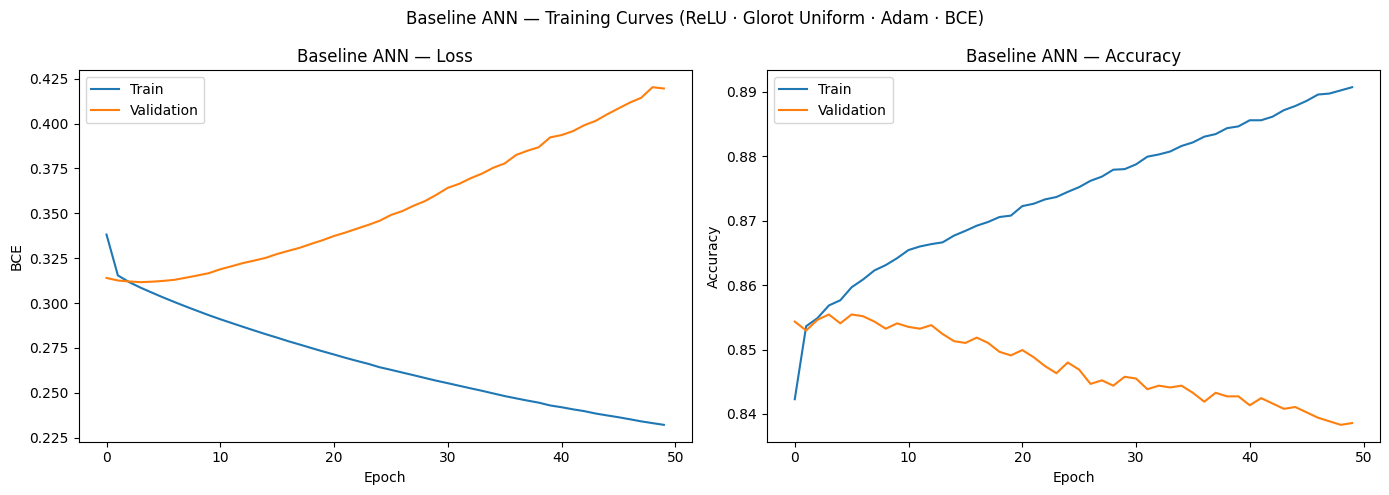

              precision    recall  f1-score   support

       <=50K     0.8639    0.9343    0.8977      6803
        >50K     0.7352    0.5535    0.6316      2242

    accuracy                         0.8399      9045
   macro avg     0.7996    0.7439    0.7646      9045
weighted avg     0.8320    0.8399    0.8318      9045



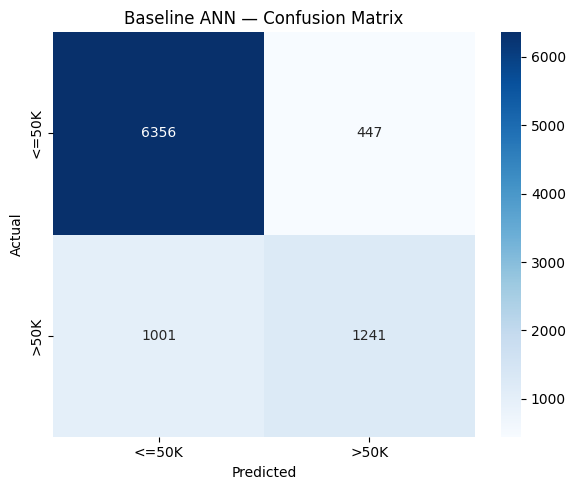

{'Test Acc': 0.8399, 'Prec(1)': 0.7352, 'Recall(1)': 0.5535, 'F1(1)': 0.6316, 'ROC-AUC': 0.8878}


In [13]:
# 2.3 Train baseline for 50 epochs
history_base=fit_ann(model_base,X_fit,y_fit,X_val,y_val,epochs=EPOCHS_50)

fig,ax=plt.subplots(1,2,figsize=(14,5))
ax[0].plot(history_base.history["loss"],label="Train"); ax[0].plot(history_base.history["val_loss"],label="Validation")
ax[0].set_title("Baseline ANN — Loss"); ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("BCE"); ax[0].legend()
ax[1].plot(history_base.history["accuracy"],label="Train"); ax[1].plot(history_base.history["val_accuracy"],label="Validation")
ax[1].set_title("Baseline ANN — Accuracy"); ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Accuracy"); ax[1].legend()
fig.suptitle("Baseline ANN — Training Curves (ReLU · Glorot Uniform · Adam · BCE)")
plt.tight_layout(); plt.savefig(f"{PLOTS_DIR}/baseline_training_curves.png",dpi=150); plt.show()

base_eval=evaluate(model_base,X_test,y_test)
print(classification_report(y_test,base_eval["y_pred"],target_names=["<=50K",">50K"],digits=4))
cm=confusion_matrix(y_test,base_eval["y_pred"])
plt.figure(figsize=(6,5)); sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["<=50K",">50K"],yticklabels=["<=50K",">50K"])
plt.title("Baseline ANN — Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout(); plt.savefig(f"{PLOTS_DIR}/baseline_confusion_matrix.png",dpi=150); plt.show()
print({k:round(base_eval[k],4) for k in ["Test Acc","Prec(1)","Recall(1)","F1(1)","ROC-AUC"]})

### Why tabular data suits an MLP

The Adult dataset is structured data: each row is a person and each feature is numeric or an encoded category. A fully connected MLP can learn nonlinear feature interactions such as age × education or hours × occupation. This is the natural ANN architecture for this kind of tabular input. fileciteturn0file0L245-L253

# Task 3: Activation Functions — Comparison Experiment

**Objective:** Compare ReLU, Tanh, Sigmoid and ELU while holding all other choices fixed.

The brief requires four 50-epoch experiments, a 2×2 comparison, ReLU dead-neuron analysis, sigmoid gradient analysis and a summary table. fileciteturn0file0L254-L304

===== relu =====
Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8407 - loss: 0.3403 - val_accuracy: 0.8516 - val_loss: 0.3160
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8533 - loss: 0.3151 - val_accuracy: 0.8530 - val_loss: 0.3138
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8554 - loss: 0.3111 - val_accuracy: 0.8538 - val_loss: 0.3128
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8572 - loss: 0.3079 - val_accuracy: 0.8554 - val_loss: 0.3127
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8587 - loss: 0.3049 - val_accuracy: 0.8560 - val_loss: 0.3130
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8598 - loss: 0.3023 - val_accuracy: 0.8563 - val_loss: 0.3138
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8611 - loss: 0.2995 - val_accuracy: 0.8554 - val_loss: 0.3143
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8620 - loss: 0.296

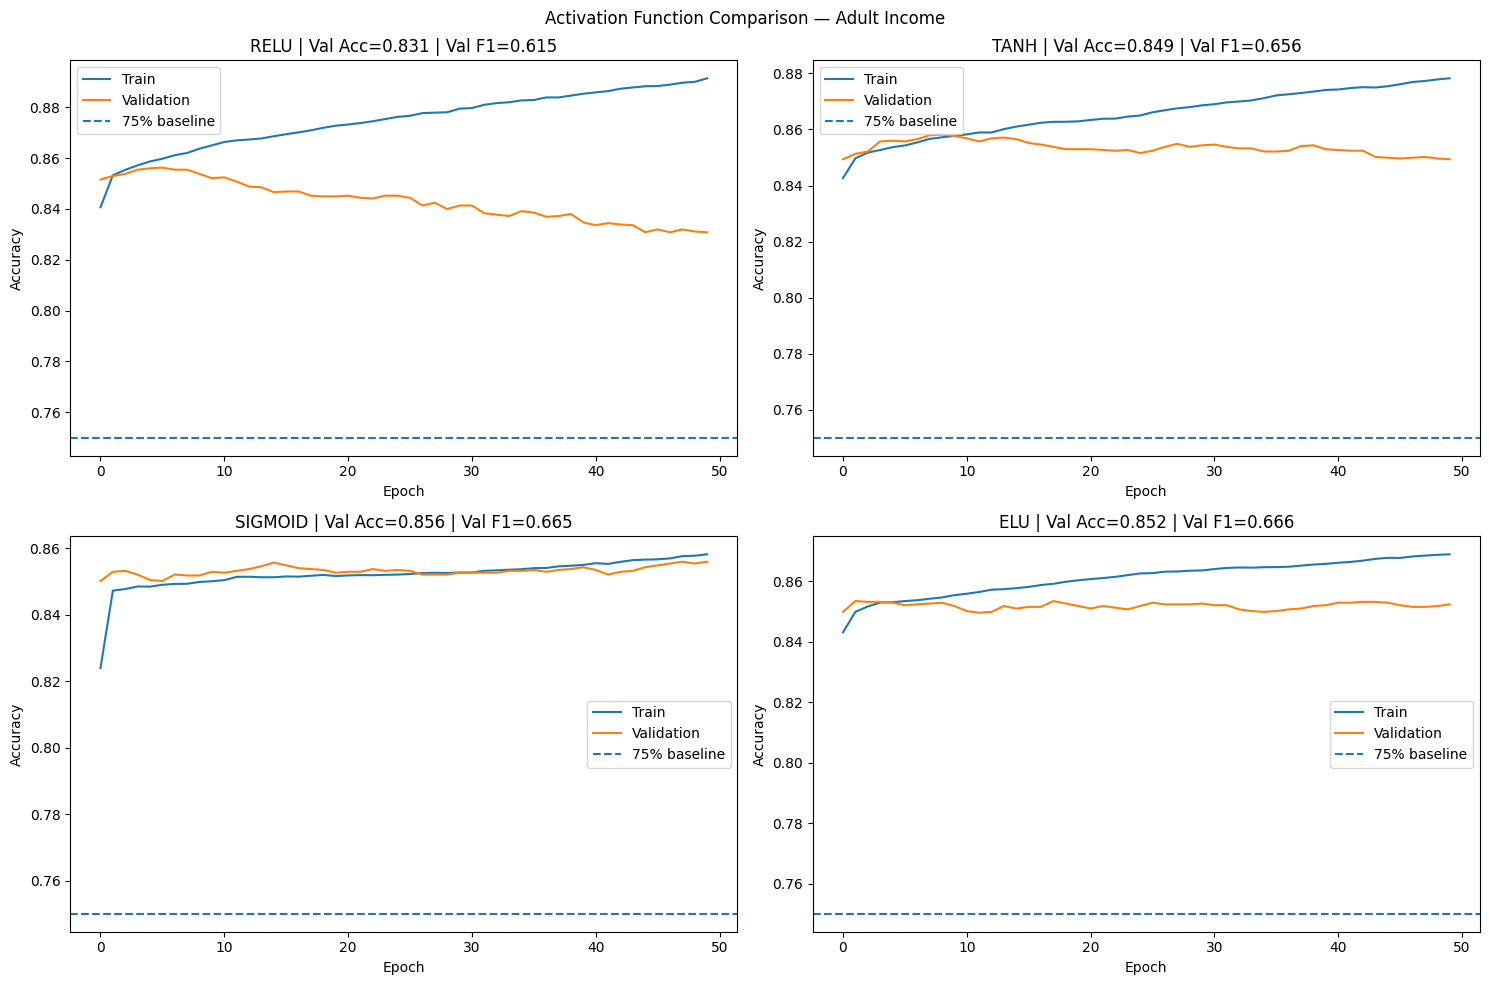

In [14]:
# 3.1 Train four activation variants
activation_models={}; activation_histories={}
for act in ["relu","tanh","sigmoid","elu"]:
    print("=====",act,"=====")
    m=build_ann(input_dim=input_dim,activation=act,initializer="glorot_uniform",optimizer="adam",loss="binary_crossentropy")
    h=fit_ann(m,X_fit,y_fit,X_val,y_val,epochs=EPOCHS_50)
    activation_models[act]=m; activation_histories[act]=h

fig,axes=plt.subplots(2,2,figsize=(15,10)); axes=axes.ravel()
for ax,act in zip(axes,["relu","tanh","sigmoid","elu"]):
    h=activation_histories[act].history
    ax.plot(h["accuracy"],label="Train"); ax.plot(h["val_accuracy"],label="Validation"); ax.axhline(.75,ls="--",label="75% baseline")
    ax.set_title(f"{act.upper()} | Val Acc={h['val_accuracy'][-1]:.3f} | Val F1={h['val_f1'][-1]:.3f}"); ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy"); ax.legend()
plt.suptitle("Activation Function Comparison — Adult Income"); plt.tight_layout(); plt.savefig(f"{PLOTS_DIR}/activation_comparison.png",dpi=150); plt.show()

RELU DEAD-NEURON ANALYSIS
Dead activation fraction: 51.4594%
Activation shape: (500, 64)


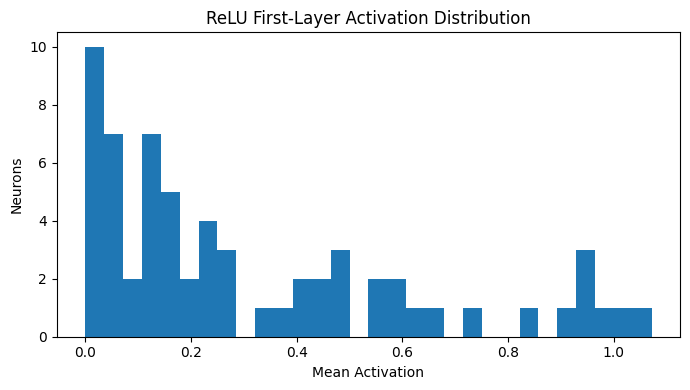


SIGMOID GRADIENT FLOW
Layer 1: 0.00021686
Layer 2: 0.00015840
Layer 3: 0.00408143


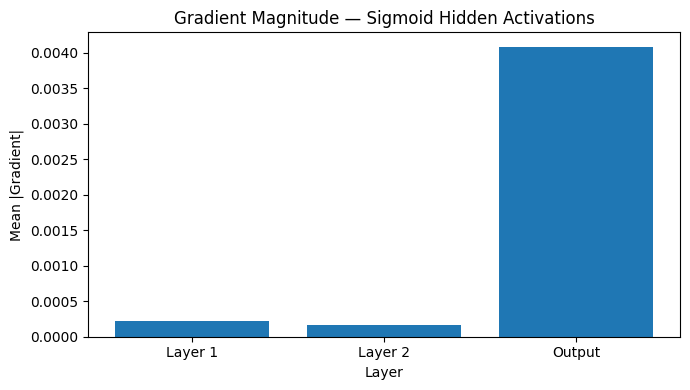

In [15]:
# ============================================================
# ReLU Dead Neurons + Sigmoid Gradient Flow
# COMPLETE STANDALONE CODE
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------

df = pd.read_csv("adult.csv")

# Clean text
for col in df.select_dtypes("object").columns:
    df[col] = df[col].str.strip()

# Missing values
df.replace("?", np.nan, inplace=True)
df.dropna(inplace=True)

# Remove unnecessary columns
df.drop(
    columns=["fnlwgt", "education"],
    inplace=True,
    errors="ignore"
)

# Target
df["income"] = (
    df["income"].eq(">50K").astype("int32")
)

# ------------------------------------------------------------
# 2. Prepare X and y
# ------------------------------------------------------------

X = df.drop(columns="income")
y = df["income"]

# One-hot encoding
X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=np.float32
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Scale numeric columns
numeric_cols = [
    c for c in [
        "age",
        "educational-num",
        "capital-gain",
        "capital-loss",
        "hours-per-week"
    ]
    if c in X_train.columns
]

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

X_test[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

y_train = y_train.astype("float32")
y_test = y_test.astype("float32")

# ------------------------------------------------------------
# 3. Create ReLU and Sigmoid models
# ------------------------------------------------------------

input_dim = X_train.shape[1]

def create_model(activation):

    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        layers.Dense(128, activation=activation),
        layers.Dense(64, activation=activation),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy"
    )

    return model


relu_model = create_model("relu")
sigmoid_model = create_model("sigmoid")

# Small training only for the diagnostic
relu_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    verbose=0
)

sigmoid_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    verbose=0
)

# ============================================================
# 3.3 ReLU Dead-Neuron Diagnostic
# ============================================================

# Build model to output first ReLU layer
inp = keras.Input(
    shape=(input_dim,)
)

x = inp

for layer in relu_model.layers:

    x = layer(x)

    if isinstance(layer, layers.Dense) and layer.units == 128:
        # Next layer is ReLU, so continue one more layer
        continue

    if (
        isinstance(layer, layers.Activation)
        or (
            hasattr(layer, "activation")
            and layer.activation.__name__ == "relu"
        )
    ):
        break

relu_activation_model = keras.Model(
    inp,
    x
)

# First 500 samples
act = relu_activation_model.predict(
    X_test.iloc[:500],
    verbose=0
)

dead_fraction = np.mean(act == 0)

print("=" * 50)
print("RELU DEAD-NEURON ANALYSIS")
print("=" * 50)

print(
    f"Dead activation fraction: {dead_fraction:.4%}"
)

print(
    f"Activation shape: {act.shape}"
)

# Plot
plt.figure(figsize=(7, 4))

plt.hist(
    act.mean(axis=0),
    bins=30
)

plt.title(
    "ReLU First-Layer Activation Distribution"
)

plt.xlabel(
    "Mean Activation"
)

plt.ylabel(
    "Neurons"
)

plt.tight_layout()
plt.show()


# ============================================================
# 3.4 Sigmoid Gradient Flow
# ============================================================

xb = tf.convert_to_tensor(
    X_train.iloc[:64].values,
    dtype=tf.float32
)

yb = tf.convert_to_tensor(
    y_train.iloc[:64].values.reshape(-1, 1),
    dtype=tf.float32
)

with tf.GradientTape() as tape:

    pred = sigmoid_model(
        xb,
        training=True
    )

    loss = tf.reduce_mean(
        keras.losses.binary_crossentropy(
            yb,
            pred
        )
    )

gradients = tape.gradient(
    loss,
    sigmoid_model.trainable_weights
)

gradient_values = []

# Dense kernels occur at indices 0, 2, 4
for i in [0, 2, 4]:

    if gradients[i] is not None:

        gradient_values.append(
            float(
                tf.reduce_mean(
                    tf.abs(gradients[i])
                ).numpy()
            )
        )

print("\n" + "=" * 50)
print("SIGMOID GRADIENT FLOW")
print("=" * 50)

for i, value in enumerate(
    gradient_values,
    start=1
):

    print(
        f"Layer {i}: {value:.8f}"
    )

# Plot
plt.figure(figsize=(7, 4))

plt.bar(
    ["Layer 1", "Layer 2", "Output"],
    gradient_values
)

plt.title(
    "Gradient Magnitude — Sigmoid Hidden Activations"
)

plt.xlabel("Layer")
plt.ylabel("Mean |Gradient|")

plt.tight_layout()
plt.show()

### Activation theory and recommendation

- **ReLU:** `max(0,x)`; fast and strong gradient on positive inputs, but can create dead neurons.
- **Tanh:** `(-1,1)` and zero-centred, but can saturate and cause vanishing gradients.
- **Sigmoid hidden:** `(0,1)` but high saturation/vanishing-gradient risk because `σ'(x) ≤ 0.25`.
- **ELU:** negative inputs remain negative and differentiable, reducing dead-neuron risk.
- **Sigmoid output:** appropriate for the final binary probability regardless of the hidden activation.

Use the actual validation F1 from the next cell as the recommendation rather than inventing a result.

In [16]:
# 3.5 Activation summary table
activation_summary=pd.DataFrame({
    "Activation":["ReLU","Tanh","Sigmoid (hidden)","ELU","Sigmoid (output only)"],
    "Formula":["max(0,x)","tanh(x)","1/(1+e^-x)","x if x>0 else α(e^x-1)","1/(1+e^-x)"],
    "Output Range":["[0,∞)","(-1,1)","(0,1)","(-α,∞)","(0,1)"],
    "Zero-Centred":["No","Yes","No","Approximately","No"],
    "Vanishing Risk":["Low/Moderate","Moderate/High","High","Low","Output use"],
    "Dead Neuron Risk":["Yes","No","No","Very Low","N/A"],
    "Val Accuracy":[activation_histories[a].history["val_accuracy"][-1] for a in ["relu","tanh","sigmoid","elu"]]+["Correct binary output"]
})
display(activation_summary)
best_activation=max(["relu","tanh","sigmoid","elu"],key=lambda a:activation_histories[a].history["val_f1"][-1])
print("Best activation by validation F1:",best_activation)

,Activation,Formula,Output Range,Zero-Centred,Vanishing Risk,Dead Neuron Risk,Val Accuracy
0,ReLU,"max(0,x)","[0,∞)",No,Low/Moderate,Yes,0.830846
1,Tanh,tanh(x),"(-1,1)",Yes,Moderate/High,No,0.849364
2,Sigmoid (hidden),1/(1+e^-x),"(0,1)",No,High,No,0.855998
3,ELU,x if x>0 else α(e^x-1),"(-α,∞)",Approximately,Low,Very Low,0.852405
4,Sigmoid (output only),1/(1+e^-x),"(0,1)",No,Output use,N/A,Correct binary output


Best activation by validation F1: elu


# Task 4: Weight Initialization Techniques

**Objective:** Compare Glorot Uniform, Glorot Normal, He Uniform, He Normal and Zeros.

The brief requires all five, convergence comparison, zero-initialization failure, symmetry explanation and initial-vs-trained weight distributions. fileciteturn0file0L306-L359

### Initialization theory

Zero initialization causes symmetry: all neurons in a layer produce the same output, receive the same gradient and remain identical. Glorot/Xavier uses approximately `Var(W)=2/(fan_in+fan_out)`, while He uses `Var(W)=2/fan_in`, making He especially suitable for ReLU networks.

===== glorot_uniform =====
Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8438 - loss: 0.3355 - val_accuracy: 0.8538 - val_loss: 0.3156
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8525 - loss: 0.3152 - val_accuracy: 0.8530 - val_loss: 0.3134
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8545 - loss: 0.3116 - val_accuracy: 0.8527 - val_loss: 0.3128
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8559 - loss: 0.3089 - val_accuracy: 0.8543 - val_loss: 0.3125
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8565 - loss: 0.3064 - val_accuracy: 0.8568 - val_loss: 0.3123
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8583 - loss: 0.3039 - val_accuracy: 0.8568 - val_loss: 0.3125
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8594 - loss: 0.3015 - val_accuracy: 0.8568 - val_loss: 0.3127
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8610 - loss

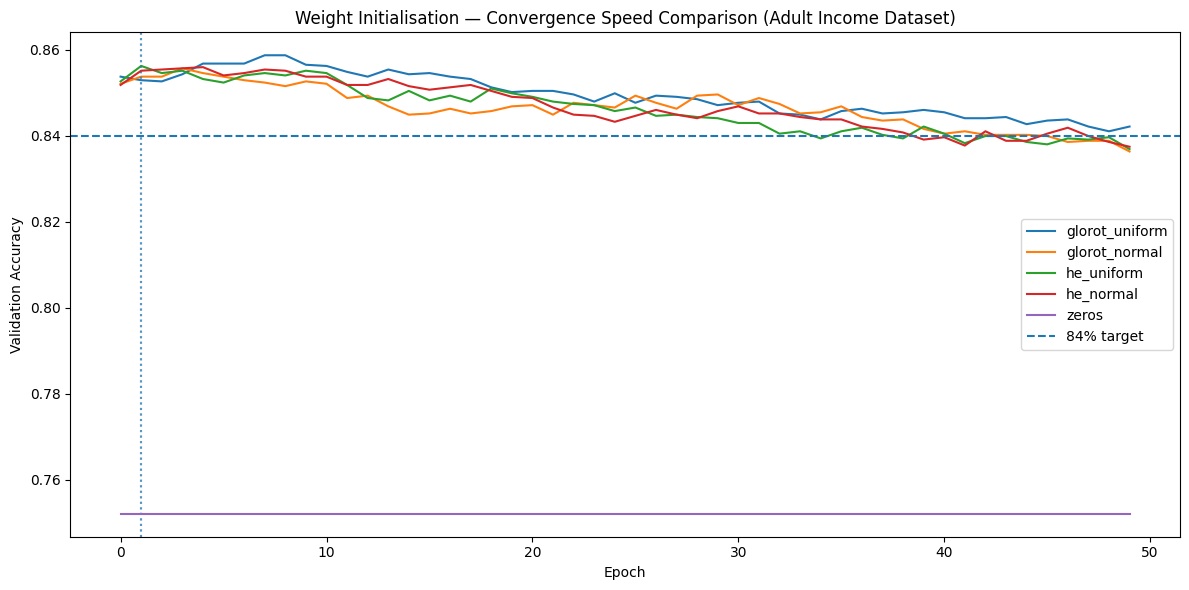

In [17]:
# 4.1 Train all five initializers
initializers=["glorot_uniform","glorot_normal","he_uniform","he_normal","zeros"]
initializer_models={}; initializer_histories={}
for init in initializers:
    print("=====",init,"=====")
    m=build_ann(input_dim=input_dim,activation="relu",initializer=init,optimizer="adam",loss="binary_crossentropy")
    h=fit_ann(m,X_fit,y_fit,X_val,y_val,epochs=EPOCHS_50)
    initializer_models[init]=m; initializer_histories[init]=h

plt.figure(figsize=(12,6))
for init in initializers:
    va=np.asarray(initializer_histories[init].history["val_accuracy"]); plt.plot(va,label=init)
    crossed=np.where(va>=.82)[0]
    if len(crossed): plt.axvline(crossed[0]+1,ls=":",alpha=.3)
plt.axhline(.84,ls="--",label="84% target"); plt.title("Weight Initialisation — Convergence Speed Comparison (Adult Income Dataset)"); plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy"); plt.legend(); plt.tight_layout(); plt.savefig(f"{PLOTS_DIR}/initialiser_convergence.png",dpi=150); plt.show()

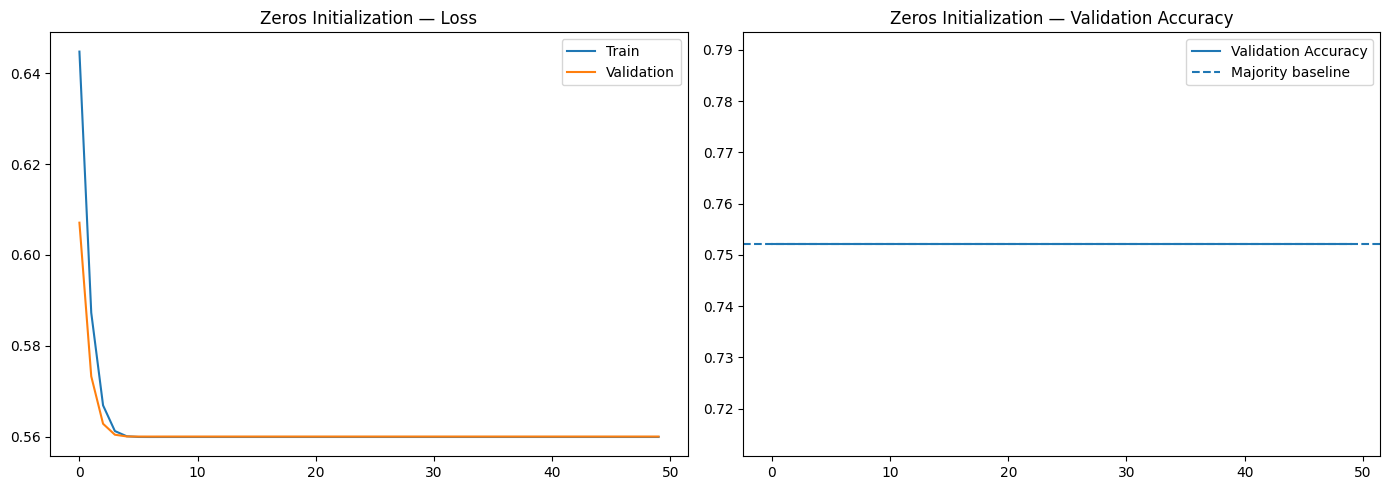

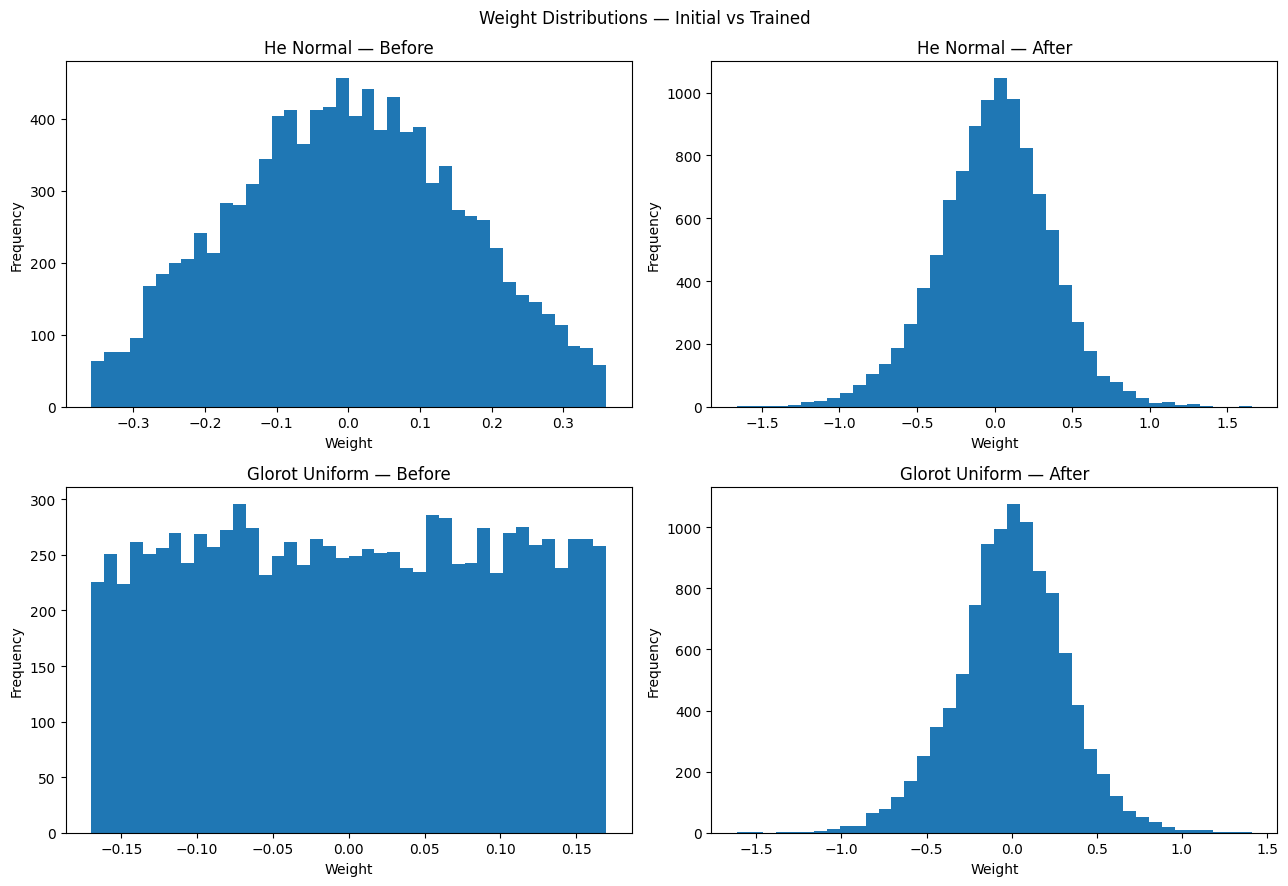

Best initializer by validation F1: glorot_uniform


In [18]:
# 4.4 Zero failure plot + 4.5 weight distributions
zh=initializer_histories["zeros"].history
fig,ax=plt.subplots(1,2,figsize=(14,5)); ax[0].plot(zh["loss"],label="Train"); ax[0].plot(zh["val_loss"],label="Validation"); ax[0].set_title("Zeros Initialization — Loss"); ax[0].legend(); ax[1].plot(zh["val_accuracy"],label="Validation Accuracy"); ax[1].axhline(y_train.value_counts(normalize=True).max(),ls="--",label="Majority baseline"); ax[1].set_title("Zeros Initialization — Validation Accuracy"); ax[1].legend(); plt.tight_layout(); plt.savefig(f"{PLOTS_DIR}/zeros_failure.png",dpi=150); plt.show()

he0=build_ann(input_dim,activation="relu",initializer="he_normal"); gl0=build_ann(input_dim,activation="relu",initializer="glorot_uniform")
he_before=he0.get_layer("dense_1").get_weights()[0].ravel(); gl_before=gl0.get_layer("dense_1").get_weights()[0].ravel()
he_after=initializer_models["he_normal"].get_layer("dense_1").get_weights()[0].ravel(); gl_after=initializer_models["glorot_uniform"].get_layer("dense_1").get_weights()[0].ravel()
fig,ax=plt.subplots(2,2,figsize=(13,9));
for a,w,t in zip(ax.ravel(),[he_before,he_after,gl_before,gl_after],["He Normal — Before","He Normal — After","Glorot Uniform — Before","Glorot Uniform — After"]): a.hist(w,bins=40); a.set_title(t); a.set_xlabel("Weight"); a.set_ylabel("Frequency")
plt.suptitle("Weight Distributions — Initial vs Trained"); plt.tight_layout(); plt.savefig(f"{PLOTS_DIR}/weight_distributions.png",dpi=150); plt.show()
best_initializer=max(initializers,key=lambda i:initializer_histories[i].history["val_f1"][-1]); print("Best initializer by validation F1:",best_initializer)

# Task 5: Loss Functions

**Objective:** Compare BCE, MSE, Weighted BCE and Focal Loss. BCE is the natural loss for binary classification; weighted BCE and Focal Loss address class imbalance. fileciteturn0file0L360-L419

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8413 - loss: 0.1092 - val_accuracy: 0.8510 - val_loss: 0.1013
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8533 - loss: 0.1011 - val_accuracy: 0.8516 - val_loss: 0.1007
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8559 - loss: 0.0996 - val_accuracy: 0.8541 - val_loss: 0.1005
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8577 - loss: 0.0984 - val_accuracy: 0.8554 - val_loss: 0.1004
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8600 - loss: 0.0972 - val_accuracy: 0.8546 - val_loss: 0.1002
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8620 - loss: 0.0962 - val_accuracy: 0.8549 - val_loss: 0.1001
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8635 - loss: 0.0953 - val_accuracy: 0.8535 - val_loss: 0.1003
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8649 - loss: 0.0944 - val_accuracy: 0.

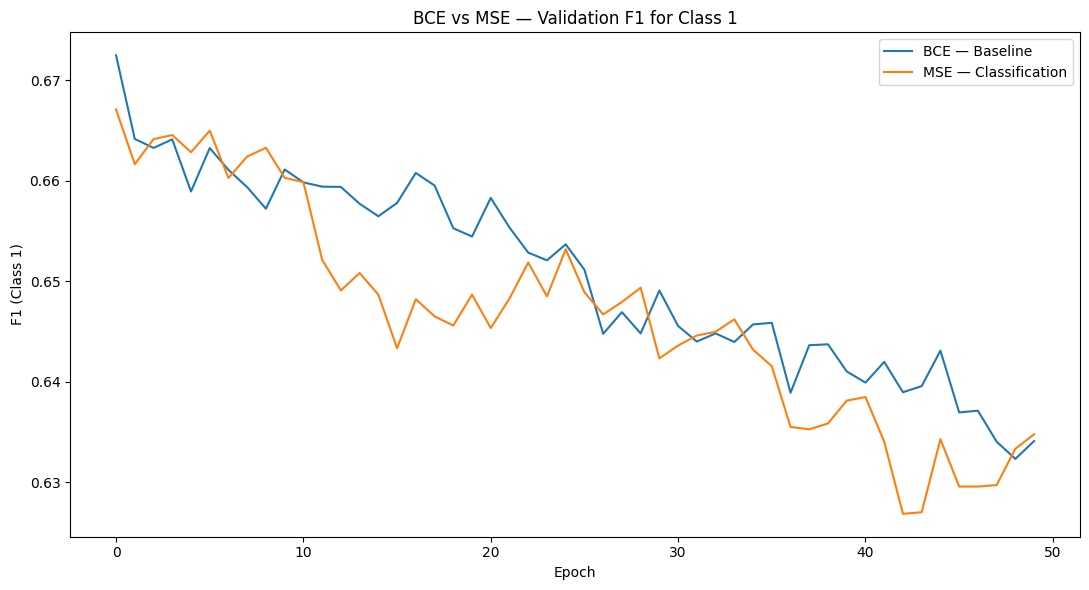

Class weights: {0: 0.6647407104940792, 1: 2.017536249845086}
Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7997 - loss: 0.3949 - val_accuracy: 0.8076 - val_loss: 0.3720
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8113 - loss: 0.3717 - val_accuracy: 0.8176 - val_loss: 0.3650
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8149 - loss: 0.3661 - val_accuracy: 0.8209 - val_loss: 0.3615
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8169 - loss: 0.3620 - val_accuracy: 0.8212 - val_loss: 0.3609
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8187 - loss: 0.3583 - val_accuracy: 0.8237 - val_loss: 0.3602
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8205 - loss: 0.3548 - val_accuracy: 0.8242 - val_loss: 0.3592
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8224 - loss: 0.3514 - val_accuracy: 0.8234 - val_loss: 0.3588
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 5s 

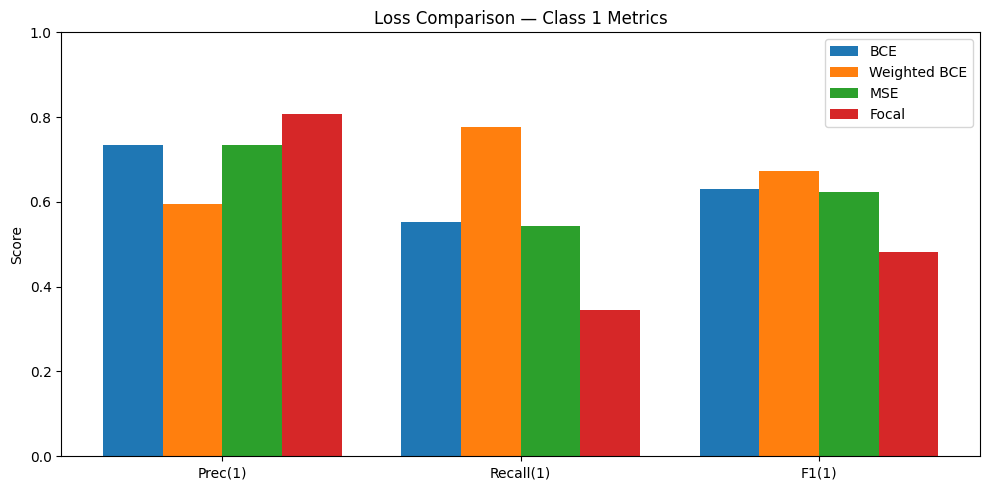

In [19]:
# 5.1 BCE baseline already uses binary_crossentropy. 5.2 MSE experiment.
model_mse=build_ann(input_dim,activation="relu",initializer="he_normal",loss="mean_squared_error")
history_mse=fit_ann(model_mse,X_fit,y_fit,X_val,y_val,epochs=EPOCHS_50)
plt.figure(figsize=(11,6)); plt.plot(history_base.history["val_f1"],label="BCE — Baseline"); plt.plot(history_mse.history["val_f1"],label="MSE — Classification"); plt.title("BCE vs MSE — Validation F1 for Class 1"); plt.xlabel("Epoch"); plt.ylabel("F1 (Class 1)"); plt.legend(); plt.tight_layout(); plt.savefig(f"{PLOTS_DIR}/loss_f1_comparison.png",dpi=150); plt.show()

# 5.3 Weighted BCE
w=compute_class_weight(class_weight="balanced",classes=np.array([0,1]),y=y_fit); class_weight_dict={0:float(w[0]),1:float(w[1])}; print("Class weights:",class_weight_dict)
model_wbce=build_ann(input_dim,activation="relu",initializer="he_normal",loss="binary_crossentropy")
history_wbce=fit_ann(model_wbce,X_fit,y_fit,X_val,y_val,epochs=EPOCHS_50,class_weight=class_weight_dict)
wbce_eval=evaluate(model_wbce,X_test,y_test)

# 5.4 Focal Loss
def focal_loss(gamma=2.0,alpha=0.25):
    def loss(y_true,y_pred):
        y_true=tf.cast(y_true,tf.float32); y_pred=tf.clip_by_value(y_pred,1e-7,1-1e-7)
        bce=-y_true*tf.math.log(y_pred)-(1-y_true)*tf.math.log(1-y_pred)
        wt=alpha*y_true*tf.pow(1-y_pred,gamma)+(1-alpha)*(1-y_true)*tf.pow(y_pred,gamma)
        return tf.reduce_mean(wt*bce)
    return loss
model_focal=build_ann(input_dim,activation="relu",initializer="he_normal",loss=focal_loss())
history_focal=fit_ann(model_focal,X_fit,y_fit,X_val,y_val,epochs=EPOCHS_50)
focal_eval=evaluate(model_focal,X_test,y_test)

mse_eval=evaluate(model_mse,X_test,y_test)
print("Baseline:", {k:round(base_eval[k],4) for k in ["Prec(1)","Recall(1)","F1(1)"]})
print("Weighted BCE:", {k:round(wbce_eval[k],4) for k in ["Prec(1)","Recall(1)","F1(1)"]})
print("MSE:", {k:round(mse_eval[k],4) for k in ["Prec(1)","Recall(1)","F1(1)"]})
print("Focal:", {k:round(focal_eval[k],4) for k in ["Prec(1)","Recall(1)","F1(1)"]})

metric_names=["Prec(1)","Recall(1)","F1(1)"]; x=np.arange(3); width=.2
plt.figure(figsize=(10,5)); plt.bar(x-1.5*width,[base_eval[m] for m in metric_names],width,label="BCE"); plt.bar(x-.5*width,[wbce_eval[m] for m in metric_names],width,label="Weighted BCE"); plt.bar(x+.5*width,[mse_eval[m] for m in metric_names],width,label="MSE"); plt.bar(x+1.5*width,[focal_eval[m] for m in metric_names],width,label="Focal"); plt.xticks(x,metric_names); plt.ylim(0,1); plt.ylabel("Score"); plt.title("Loss Comparison — Class 1 Metrics"); plt.legend(); plt.tight_layout(); plt.savefig(f"{PLOTS_DIR}/loss_metrics_comparison.png",dpi=150); plt.show()

### Loss explanation

BCE is `-[y log(p)+(1-y)log(1-p)]`. With sigmoid output, its useful gradient form is `p-y`. MSE introduces an additional sigmoid derivative factor, which can become very small when the sigmoid saturates. Weighted BCE changes the contribution of classes, while Focal Loss uses `(1-p)^gamma`-type factors to focus on hard examples.

# Task 6: Batch Normalization

**Objective:** Compare a canonical `Dense → BatchNorm → ReLU` model against the baseline, test BN placement, and inspect gamma/beta. fileciteturn0file0L424-L483

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,457 (76.00 KB)

 Trainable params: 19,073 (74.50 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8372 - loss: 0.3474 - val_accuracy: 0.8543 - val_loss: 0.3169
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8504 - loss: 0.3188 - val_accuracy: 0.8557 - val_loss: 0.3144
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8543 - loss: 0.3117 - val_accuracy: 0.8557 - val_loss: 0.3140
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8567 - loss: 0.3065 - val_accuracy: 0.8535 - val_loss: 0.3146
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8591 - loss: 0.3023 - val_accuracy: 0.8521 - val_loss: 0.3148
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8615 - loss: 0.2984 - val_accuracy: 0.8530 - val_loss: 0.3149
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8634 - loss: 0.2947 - val_accuracy: 0.8519 - val_loss: 0.3155
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8651 - loss: 0.2908 - val_accuracy: 0.

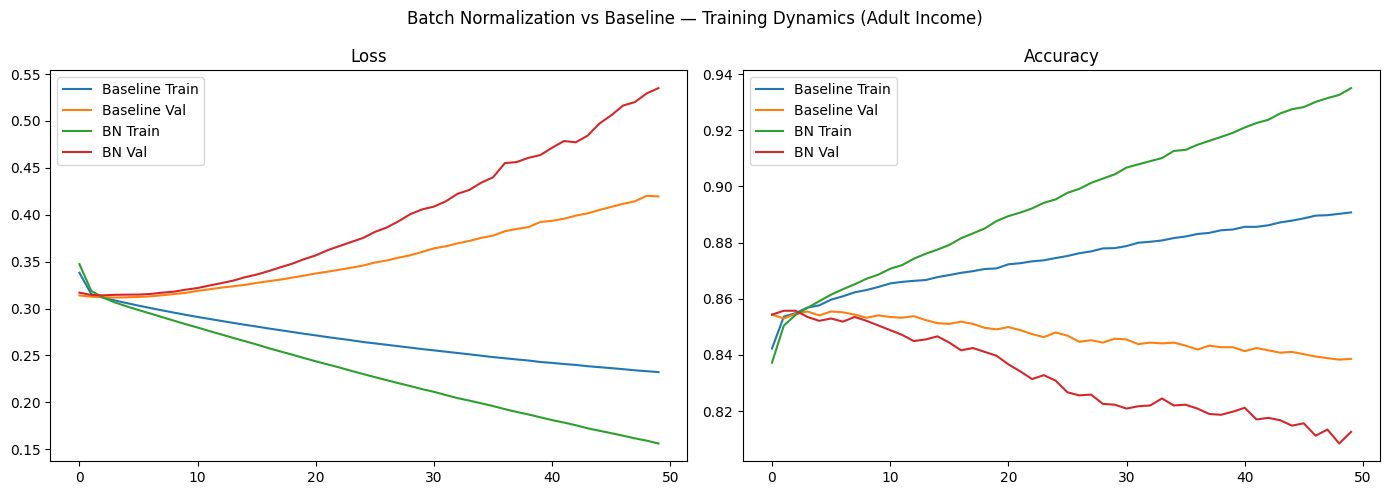

Epoch 1/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.8306 - loss: 0.3571 - val_accuracy: 0.8549 - val_loss: 0.3165
Epoch 2/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8525 - loss: 0.3178 - val_accuracy: 0.8566 - val_loss: 0.3148
Epoch 3/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8560 - loss: 0.3106 - val_accuracy: 0.8560 - val_loss: 0.3154
Epoch 4/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8586 - loss: 0.3053 - val_accuracy: 0.8557 - val_loss: 0.3162
Epoch 5/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8606 - loss: 0.3009 - val_accuracy: 0.8546 - val_loss: 0.3169
Epoch 6/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8623 - loss: 0.2965 - val_accuracy: 0.8538 - val_loss: 0.3185
Epoch 7/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8646 - loss: 0.2923 - val_accuracy: 0.8502 - val_loss: 0.3203
Epoch 8/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8665 - loss: 0.2883 - val_accuracy: 

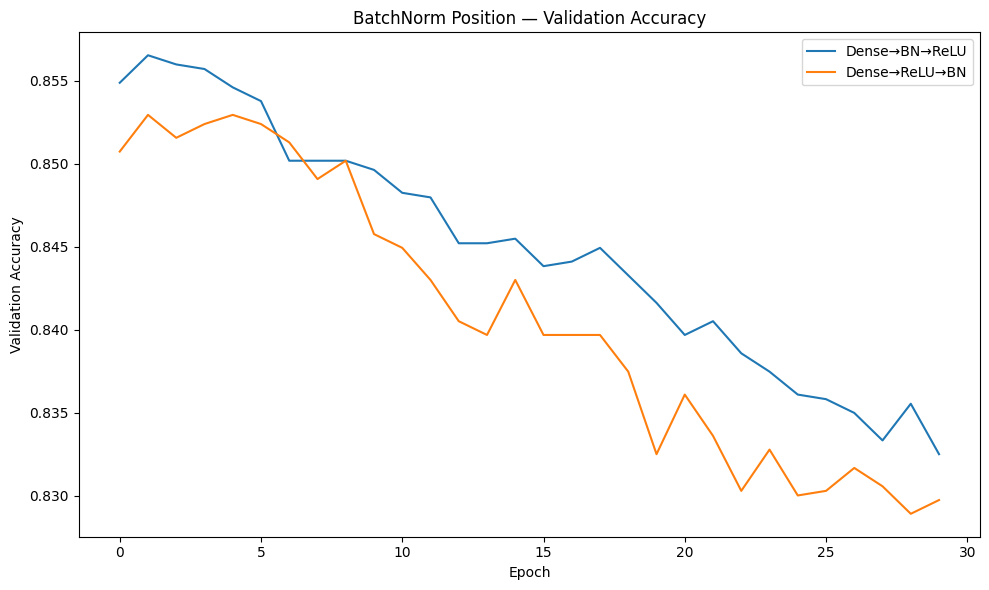

In [20]:
# 6.1 Canonical BatchNorm model
model_bn=keras.Sequential([
    keras.Input(shape=(input_dim,)),
    layers.Dense(128,kernel_initializer="he_normal",name="dense_1"), layers.BatchNormalization(name="bn_1"), layers.Activation("relu",name="relu_1"),
    layers.Dense(64,kernel_initializer="he_normal",name="dense_2"), layers.BatchNormalization(name="bn_2"), layers.Activation("relu",name="relu_2"),
    layers.Dense(1,activation="sigmoid",name="output")])
model_bn.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"]); model_bn.summary()
history_bn=fit_ann(model_bn,X_fit,y_fit,X_val,y_val,epochs=EPOCHS_50); bn_eval=evaluate(model_bn,X_test,y_test)

fig,ax=plt.subplots(1,2,figsize=(14,5))
for key,label in [("loss","Baseline Train"),("val_loss","Baseline Val")]: ax[0].plot(history_base.history[key],label=label)
for key,label in [("loss","BN Train"),("val_loss","BN Val")]: ax[0].plot(history_bn.history[key],label=label)
for key,label in [("accuracy","Baseline Train"),("val_accuracy","Baseline Val")]: ax[1].plot(history_base.history[key],label=label)
for key,label in [("accuracy","BN Train"),("val_accuracy","BN Val")]: ax[1].plot(history_bn.history[key],label=label)
ax[0].set_title("Loss"); ax[1].set_title("Accuracy"); ax[0].legend(); ax[1].legend(); fig.suptitle("Batch Normalization vs Baseline — Training Dynamics (Adult Income)"); plt.tight_layout(); plt.savefig(f"{PLOTS_DIR}/batchnorm_dynamics.png",dpi=150); plt.show()

# 6.4 BN position experiment
def build_bn_position(position):
    m=keras.Sequential([keras.Input(shape=(input_dim,))])
    for i,u in enumerate([128,64],1):
        m.add(layers.Dense(u,kernel_initializer="he_normal",name=f"dense_{i}"))
        if position=="before": m.add(layers.BatchNormalization(name=f"bn_{i}")); m.add(layers.Activation("relu",name=f"relu_{i}"))
        else: m.add(layers.Activation("relu",name=f"relu_{i}")); m.add(layers.BatchNormalization(name=f"bn_{i}"))
    m.add(layers.Dense(1,activation="sigmoid",name="output")); m.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"]); return m
mb=build_bn_position("before"); ma=build_bn_position("after")
hb=fit_ann(mb,X_fit,y_fit,X_val,y_val,epochs=EPOCHS_30); ha=fit_ann(ma,X_fit,y_fit,X_val,y_val,epochs=EPOCHS_30)
plt.figure(figsize=(10,6)); plt.plot(hb.history["val_accuracy"],label="Dense→BN→ReLU"); plt.plot(ha.history["val_accuracy"],label="Dense→ReLU→BN"); plt.title("BatchNorm Position — Validation Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy"); plt.legend(); plt.tight_layout(); plt.savefig(f"{PLOTS_DIR}/batchnorm_position.png",dpi=150); plt.show()

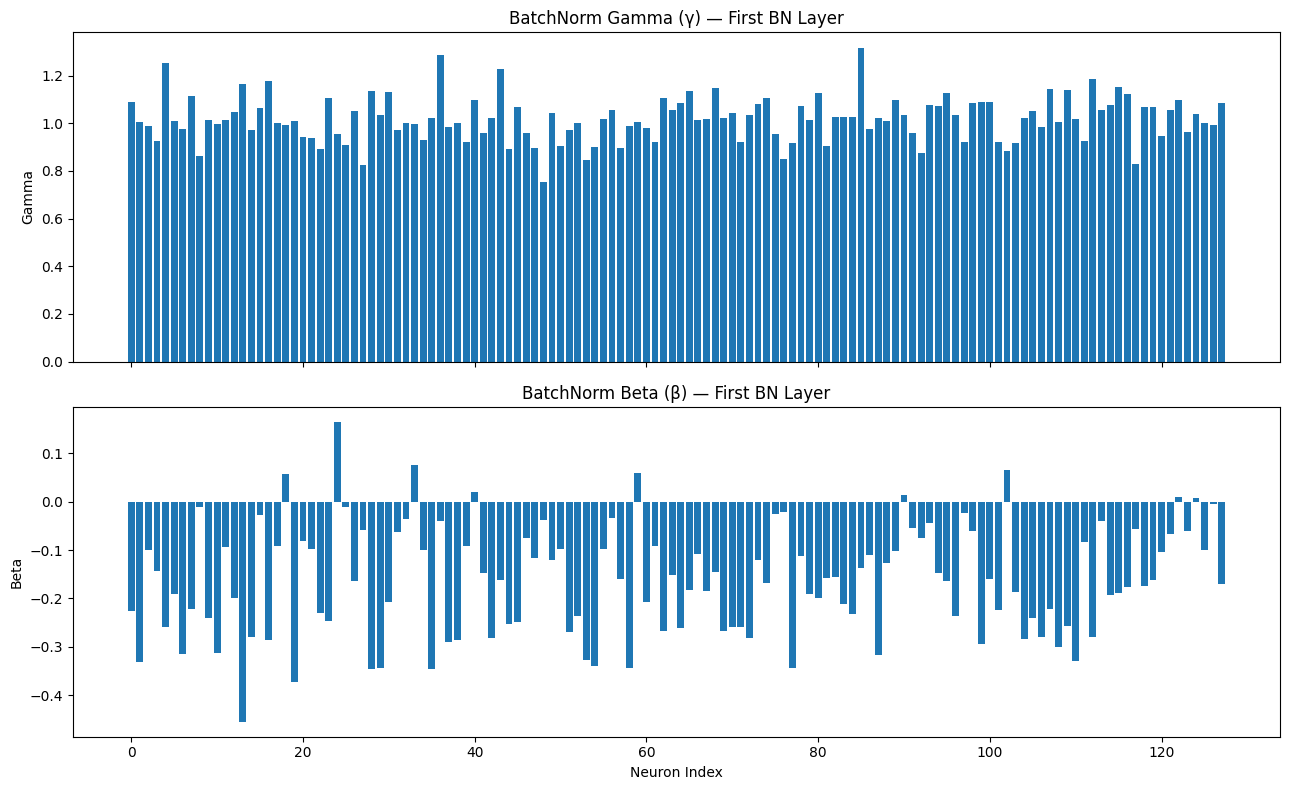

Neurons with |gamma| < 0.1: 0 / 128


In [21]:
# 6.5 Gamma and beta inspection
bn_layer=model_bn.get_layer("bn_1"); gamma,beta,running_mean,running_var=bn_layer.get_weights()
fig,ax=plt.subplots(2,1,figsize=(13,8),sharex=True); ax[0].bar(np.arange(len(gamma)),gamma); ax[0].set_title("BatchNorm Gamma (γ) — First BN Layer"); ax[0].set_ylabel("Gamma"); ax[1].bar(np.arange(len(beta)),beta); ax[1].set_title("BatchNorm Beta (β) — First BN Layer"); ax[1].set_xlabel("Neuron Index"); ax[1].set_ylabel("Beta"); plt.tight_layout(); plt.savefig(f"{PLOTS_DIR}/batchnorm_gamma_beta.png",dpi=150); plt.show()
print("Neurons with |gamma| < 0.1:",int(np.sum(np.abs(gamma)<.1)),"/",len(gamma))

### BatchNorm interpretation

During training, BN uses mini-batch mean/variance and learns gamma/beta. During inference, it uses running statistics. Gamma close to zero suppresses an internal signal; larger absolute gamma preserves it more strongly. The original project brief asks for the canonical order and a BN-position comparison. fileciteturn0file0L441-L483

# Task 7: Optimizers — Convergence & Final Comparison

**Objective:** Compare five optimizer configurations, perform SGD-vs-Adam learning-rate sensitivity, train the final combined ANN for 80 epochs, and build the full comparison table and ROC curves. fileciteturn0file0L484-L553

===== SGD =====
Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8180 - loss: 0.3936 - val_accuracy: 0.8375 - val_loss: 0.3489
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8400 - loss: 0.3454 - val_accuracy: 0.8441 - val_loss: 0.3350
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8422 - loss: 0.3369 - val_accuracy: 0.8469 - val_loss: 0.3295
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8443 - loss: 0.3324 - val_accuracy: 0.8477 - val_loss: 0.3265
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8457 - loss: 0.3292 - val_accuracy: 0.8466 - val_loss: 0.3245
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8466 - loss: 0.3267 - val_accuracy: 0.8485 - val_loss: 0.3232
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8479 - loss: 0.3247 - val_accuracy: 0.8491 - val_loss: 0.3222
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8488 - loss: 0.3230 - 

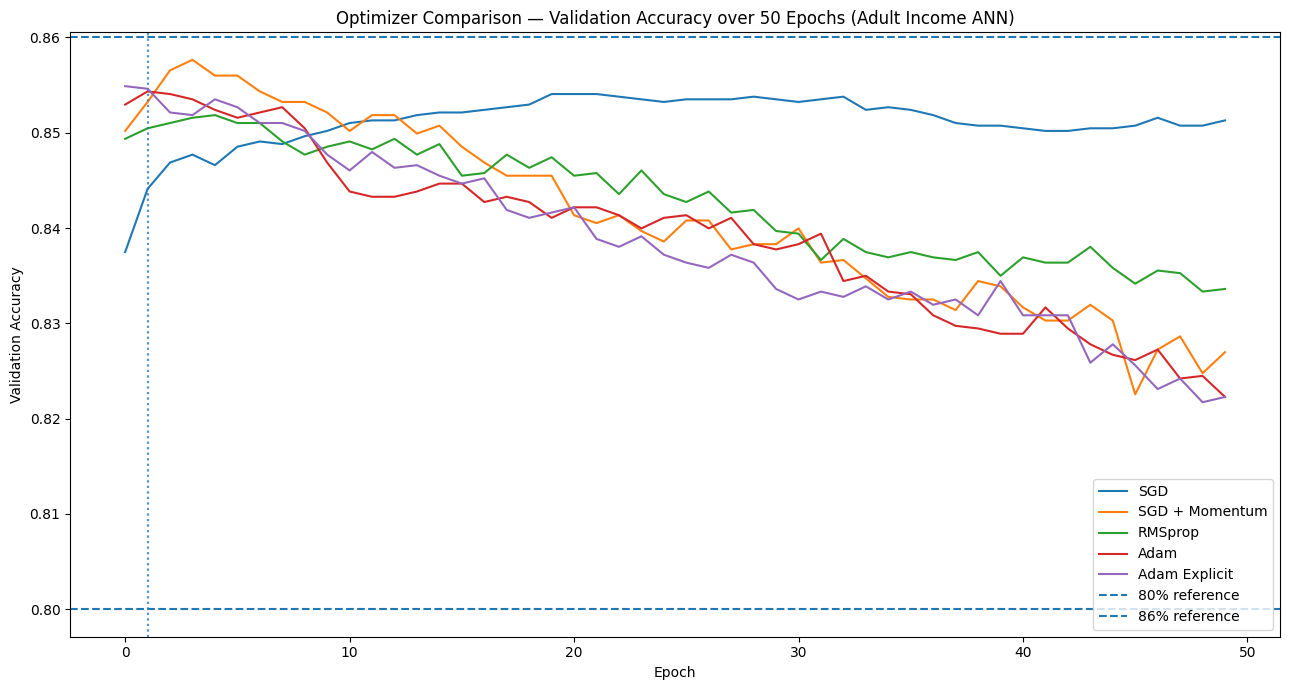

In [22]:
# 7.1 Five optimizers
optimizer_configs={
    "SGD":"sgd",
    "SGD + Momentum":keras.optimizers.SGD(learning_rate=.01,momentum=.9),
    "RMSprop":"rmsprop",
    "Adam":"adam",
    "Adam Explicit":keras.optimizers.Adam(learning_rate=.001,beta_1=.9,beta_2=.999)}
optimizer_models={}; optimizer_histories={}; optimizer_evals={}
for name,opt in optimizer_configs.items():
    print("=====",name,"=====")
    m=build_ann(input_dim,activation="relu",initializer="he_normal",use_batch_norm=True,optimizer=opt,loss="binary_crossentropy")
    h=fit_ann(m,X_fit,y_fit,X_val,y_val,epochs=EPOCHS_50); optimizer_models[name]=m; optimizer_histories[name]=h; optimizer_evals[name]=evaluate(m,X_test,y_test)

plt.figure(figsize=(13,7))
for name,h in optimizer_histories.items():
    va=np.asarray(h.history["val_accuracy"]); plt.plot(va,label=name); c=np.where(va>=.83)[0]
    if len(c): plt.axvline(c[0]+1,ls=":",alpha=.25)
plt.axhline(.80,ls="--",label="80% reference"); plt.axhline(.86,ls="--",label="86% reference"); plt.title("Optimizer Comparison — Validation Accuracy over 50 Epochs (Adult Income ANN)"); plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy"); plt.legend(); plt.tight_layout(); plt.savefig(f"{PLOTS_DIR}/optimiser_convergence.png",dpi=150); plt.show()

### Optimizer theory

- **SGD:** fixed global learning rate; simple but can be slow.
- **Momentum:** adds velocity and smooths oscillation.
- **RMSprop:** adapts updates using a running average of squared gradients.
- **Adam:** combines first-moment and second-moment adaptation with bias correction.
- **Explicit Adam:** confirms the common `lr=0.001`, `beta_1=0.9`, `beta_2=0.999` values.

Adam uses `theta = theta - lr * m_hat / sqrt(v_hat + epsilon)`. fileciteturn0file0L508-L522

,Optimizer,Final Val Acc,Final Val F1,First epoch >=83%,Test F1(1)
0,SGD,0.851299,0.669127,1,0.660084
1,SGD + Momentum,0.826976,0.613580,1,0.608071
2,RMSprop,0.833610,0.630221,1,0.625767
3,Adam,0.822277,0.589137,1,0.573571
4,Adam Explicit,0.822277,0.574454,1,0.584382


Best optimizer by test F1: SGD
Epoch 1/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3483 - loss: 0.9028 - val_accuracy: 0.3546 - val_loss: 0.8602
Epoch 2/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.4074 - loss: 0.8158 - val_accuracy: 0.4328 - val_loss: 0.7842
Epoch 3/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4793 - loss: 0.7463 - val_accuracy: 0.5100 - val_loss: 0.7216
Epoch 4/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5550 - loss: 0.6908 - val_accuracy: 0.5912 - val_loss: 0.6713
Epoch 5/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6261 - loss: 0.6462 - val_accuracy: 0.6587 - val_loss: 0.6307
Epoch 6/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6792 - loss: 0.6101 - val_accuracy: 0.6993 - val_loss: 0.5976
Epoch 7/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7165 - loss: 0.5807 - val_accuracy: 0.7275 - val_loss: 0.5704
Epoch 8/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7392 - 

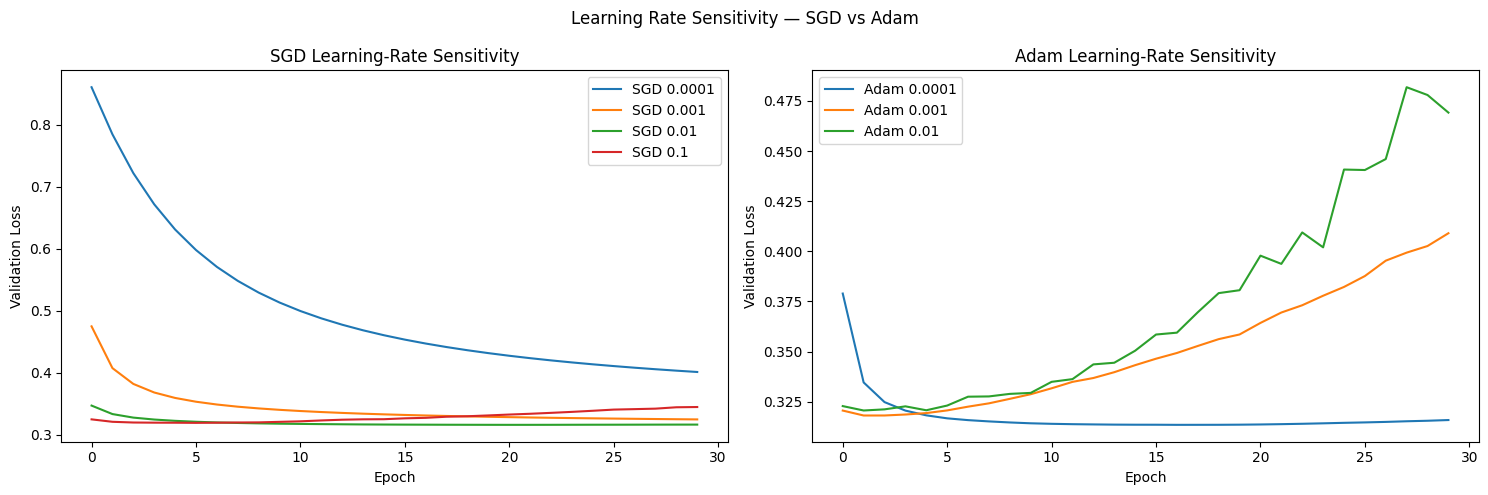

In [23]:
# 7.2 Optimizer summary and fastest convergence
opt_rows=[]
for name,h in optimizer_histories.items():
    va=np.asarray(h.history["val_accuracy"]); c=np.where(va>=.83)[0]
    opt_rows.append({"Optimizer":name,"Final Val Acc":va[-1],"Final Val F1":h.history["val_f1"][-1],"First epoch >=83%":int(c[0]+1) if len(c) else np.nan,"Test F1(1)":optimizer_evals[name]["F1(1)"]})
optimizer_summary=pd.DataFrame(opt_rows); display(optimizer_summary); print("Best optimizer by test F1:",optimizer_summary.sort_values("Test F1(1)",ascending=False).iloc[0]["Optimizer"])

# 7.4 Learning-rate sensitivity
lr_histories={}
for lr in [.0001,.001,.01,.1]:
    m=build_ann(input_dim,activation="relu",initializer="he_normal",use_batch_norm=True,optimizer=keras.optimizers.SGD(learning_rate=lr),loss="binary_crossentropy"); lr_histories[f"SGD lr={lr}"]=fit_ann(m,X_fit,y_fit,X_val,y_val,epochs=EPOCHS_30)
for lr in [.0001,.001,.01]:
    m=build_ann(input_dim,activation="relu",initializer="he_normal",use_batch_norm=True,optimizer=keras.optimizers.Adam(learning_rate=lr),loss="binary_crossentropy"); lr_histories[f"Adam lr={lr}"]=fit_ann(m,X_fit,y_fit,X_val,y_val,epochs=EPOCHS_30)
fig,ax=plt.subplots(1,2,figsize=(15,5))
for lr in [.0001,.001,.01,.1]: ax[0].plot(lr_histories[f"SGD lr={lr}"].history["val_loss"],label=f"SGD {lr}")
for lr in [.0001,.001,.01]: ax[1].plot(lr_histories[f"Adam lr={lr}"].history["val_loss"],label=f"Adam {lr}")
ax[0].set_title("SGD Learning-Rate Sensitivity"); ax[1].set_title("Adam Learning-Rate Sensitivity")
for a in ax: a.set_xlabel("Epoch"); a.set_ylabel("Validation Loss"); a.legend()
fig.suptitle("Learning Rate Sensitivity — SGD vs Adam"); plt.tight_layout(); plt.savefig(f"{PLOTS_DIR}/learning_rate_sensitivity.png",dpi=150); plt.show()

In [24]:
# 7.5 Final combined model — use weighted BCE only if it improved baseline F1
use_weighted_bce=wbce_eval["F1(1)"]>base_eval["F1(1)"]
final_loss_name="Weighted BCE" if use_weighted_bce else "BCE"
final_model=build_ann(input_dim,hidden_units=[128,64],activation="relu",initializer="he_normal",use_batch_norm=True,optimizer="adam",loss="binary_crossentropy")
history_final=fit_ann(final_model,X_fit,y_fit,X_val,y_val,epochs=EPOCHS_80,class_weight=class_weight_dict if use_weighted_bce else None)
final_eval=evaluate(final_model,X_test,y_test)
print("Final loss:",final_loss_name)
print({k:round(final_eval[k],4) for k in ["Test Acc","Prec(1)","Recall(1)","F1(1)","ROC-AUC"]})

Epoch 1/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.7903 - loss: 0.4051 - val_accuracy: 0.8098 - val_loss: 0.3817
Epoch 2/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8091 - loss: 0.3768 - val_accuracy: 0.8051 - val_loss: 0.3831
Epoch 3/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8134 - loss: 0.3681 - val_accuracy: 0.8085 - val_loss: 0.3815
Epoch 4/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8163 - loss: 0.3614 - val_accuracy: 0.8085 - val_loss: 0.3802
Epoch 5/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8189 - loss: 0.3557 - val_accuracy: 0.8065 - val_loss: 0.3842
Epoch 6/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8207 - loss: 0.3501 - val_accuracy: 0.8060 - val_loss: 0.3850
Epoch 7/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8232 - loss: 0.3449 - val_accuracy: 0.8062 - val_loss: 0.3860
Epoch 8/80
509/509 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8259 - loss: 0.3398 - val_accuracy: 

,Model,Activation,Init,Loss,BatchNorm,Optimizer,Test Acc,Prec(1),Recall(1),F1(1),ROC-AUC
0,Baseline,ReLU,Glorot Uniform,BCE,False,Adam,0.8399,0.7352,0.5535,0.6316,0.8878
1,Best Activation (elu),elu,Glorot Uniform,BCE,False,Adam,0.8504,0.7562,0.5852,0.6598,0.9056
2,Best Initializer (glorot_uniform),ReLU,glorot_uniform,BCE,False,Adam,0.8392,0.7275,0.5620,0.6341,0.8874
3,Weighted BCE,ReLU,He Normal,Weighted BCE,False,Adam,0.8138,0.5955,0.7761,0.6739,0.8877
4,Focal Loss,ReLU,He Normal,Focal Loss,False,Adam,0.8171,0.8075,0.3443,0.4828,0.8799
5,BatchNorm,ReLU,He Normal,BCE,True,Adam,0.8244,0.6734,0.5665,0.6153,0.8692
6,Final Combined,ReLU,He Normal,Weighted BCE,True,Adam,0.8087,0.6165,0.6044,0.6104,0.8570


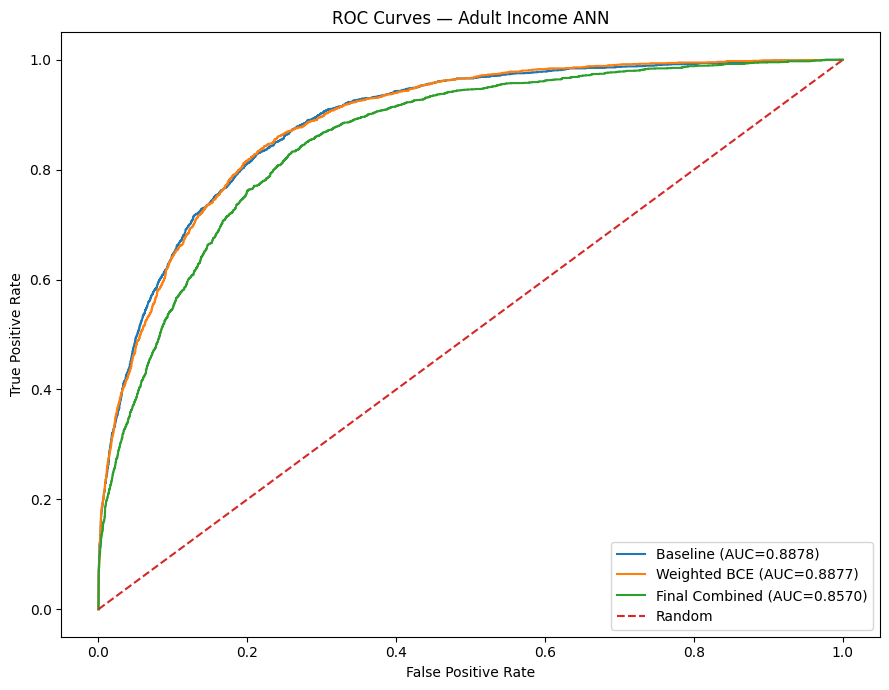

,Technique,F1 Change
2,Weighted BCE,0.042344
0,Best Activation,0.028242
1,Best Initializer,0.002570
4,BatchNorm,-0.016242
3,Focal Loss,-0.148750


Largest measured individual F1 impact: {'Technique': 'Weighted BCE', 'F1 Change': 0.042344041642768504}


In [25]:
# 7.6 Full results table + ROC curves + technique impact
rows=[]
def add(name,act,init,loss,bn,opt,e): rows.append({"Model":name,"Activation":act,"Init":init,"Loss":loss,"BatchNorm":bn,"Optimizer":opt,"Test Acc":e["Test Acc"],"Prec(1)":e["Prec(1)"],"Recall(1)":e["Recall(1)"],"F1(1)":e["F1(1)"],"ROC-AUC":e["ROC-AUC"]})
add("Baseline","ReLU","Glorot Uniform","BCE",False,"Adam",base_eval)
best_act_eval=evaluate(activation_models[best_activation],X_test,y_test); add(f"Best Activation ({best_activation})",best_activation,"Glorot Uniform","BCE",False,"Adam",best_act_eval)
best_init_eval=evaluate(initializer_models[best_initializer],X_test,y_test); add(f"Best Initializer ({best_initializer})","ReLU",best_initializer,"BCE",False,"Adam",best_init_eval)
add("Weighted BCE","ReLU","He Normal","Weighted BCE",False,"Adam",wbce_eval)
add("Focal Loss","ReLU","He Normal","Focal Loss",False,"Adam",focal_eval)
add("BatchNorm","ReLU","He Normal","BCE",True,"Adam",bn_eval)
add("Final Combined","ReLU","He Normal",final_loss_name,True,"Adam",final_eval)
results_df=pd.DataFrame(rows); display(results_df.style.highlight_max(subset=["F1(1)","ROC-AUC"],color="#ffcccc").format({c:"{:.4f}" for c in ["Test Acc","Prec(1)","Recall(1)","F1(1)","ROC-AUC"]})); results_df.to_csv(f"{PLOTS_DIR}/results_table.csv",index=False)

roc_models={"Baseline":base_eval,"Weighted BCE":wbce_eval,"Final Combined":final_eval}
plt.figure(figsize=(9,7))
for name,e in roc_models.items():
    fpr,tpr,_=roc_curve(y_test,e["y_prob"]); plt.plot(fpr,tpr,label=f"{name} (AUC={e['ROC-AUC']:.4f})")
plt.plot([0,1],[0,1],ls="--",label="Random"); plt.title("ROC Curves — Adult Income ANN"); plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.legend(); plt.tight_layout(); plt.savefig(f"{PLOTS_DIR}/roc_curves.png",dpi=150); plt.show()

impact=pd.DataFrame({"Technique":["Best Activation","Best Initializer","Weighted BCE","Focal Loss","BatchNorm"],"F1 Change":[best_act_eval["F1(1)"]-base_eval["F1(1)"],best_init_eval["F1(1)"]-base_eval["F1(1)"],wbce_eval["F1(1)"]-base_eval["F1(1)"],focal_eval["F1(1)"]-base_eval["F1(1)"],bn_eval["F1(1)"]-base_eval["F1(1)"]]}).sort_values("F1 Change",ascending=False)
display(impact); print("Largest measured individual F1 impact:",impact.iloc[0].to_dict())